In [12]:
import pandas as pd
from pathlib import Path

test = "0"
parameter = "translation_z"
scene = "transmit_2"
camera = "camera1"
csv_path = Path(f"Output/{scene}/{parameter}/{test}/{camera}_{parameter}_sweep.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)

required_columns = {f"{parameter}", "loss", "analytic_grad", "fd_grad"}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

df.head()

,iter,translation_z,loss,analytic_grad,fd_grad,fd_kind,fd_epsilon
0,0,-1.50,0.001298,-0.000211,-0.000225,0,0.005
1,1,-1.37,0.001269,-0.000238,-0.000229,0,0.005
2,2,-1.24,0.001237,-0.000256,-0.000250,0,0.005
3,3,-1.11,0.001203,-0.000267,-0.000274,0,0.005
4,4,-0.98,0.001167,-0.000281,-0.000280,0,0.005


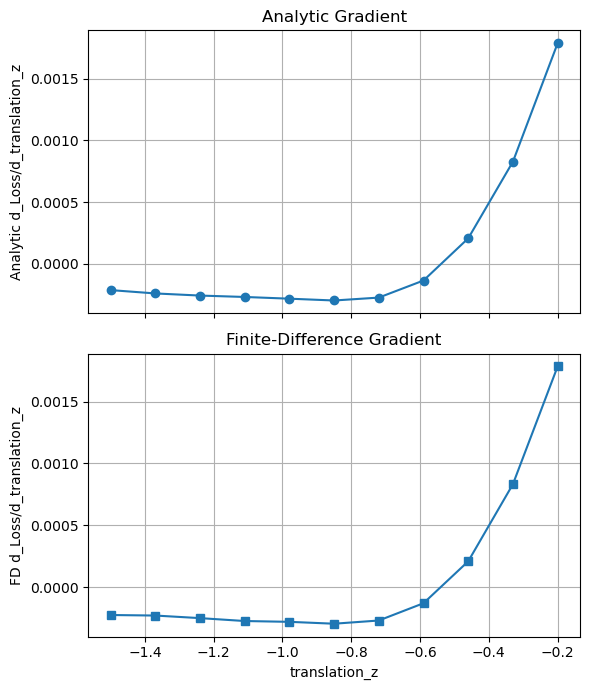

PosixPath('Output/transmit_2/translation_z/0/camera1_translation_z_sweep_grad_subplots.png')

In [13]:
import matplotlib.pyplot as plt

NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7), sharex=True)

# --- Top: Analytic ---
axes[0].plot(df[f"{parameter}"], df["analytic_grad"], marker="o")
axes[0].set_ylabel(f"Analytic d_Loss/d_{parameter}")
axes[0].set_title("Analytic Gradient")
axes[0].grid(True)

# --- Bottom: Finite Difference ---
axes[1].plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s")
axes[1].set_xlabel(f"{parameter}")
axes[1].set_ylabel(f"FD d_Loss/d_{parameter}")
axes[1].set_title("Finite-Difference Gradient")
axes[1].grid(True)

output_png = csv_path.with_name(csv_path.stem + "_grad_subplots.png")
plt.tight_layout()
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

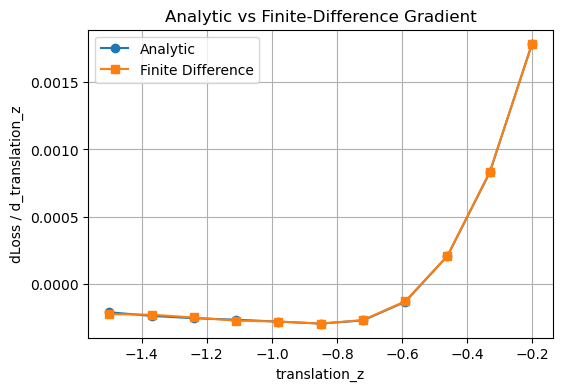

PosixPath('Output/transmit_2/translation_z/0/camera1_translation_z_sweep_grad_compare.png')

In [14]:
NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

plt.figure(figsize=(6, 4))

plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d_{parameter}")
plt.title("Analytic vs Finite-Difference Gradient")
plt.grid(True)
plt.legend()

output_png = csv_path.with_name(csv_path.stem + "_grad_compare.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

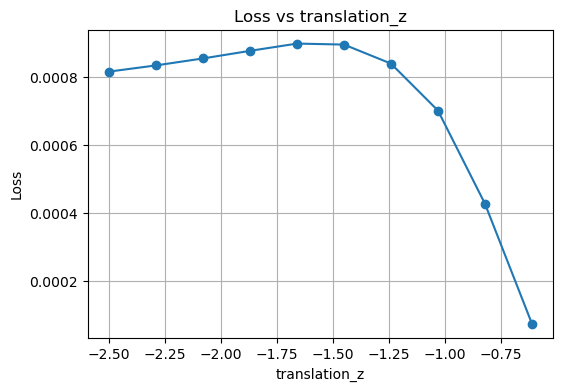

PosixPath('Output/transmit_2/translation_z/0/camera1_translation_z_sweep_loss.png')

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["loss"], marker="o")
plt.xlabel(f"{parameter}")
plt.ylabel("Loss")
plt.title(f"Loss vs {parameter}")
plt.grid(True)

output_png = csv_path.with_name(csv_path.stem + "_loss.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

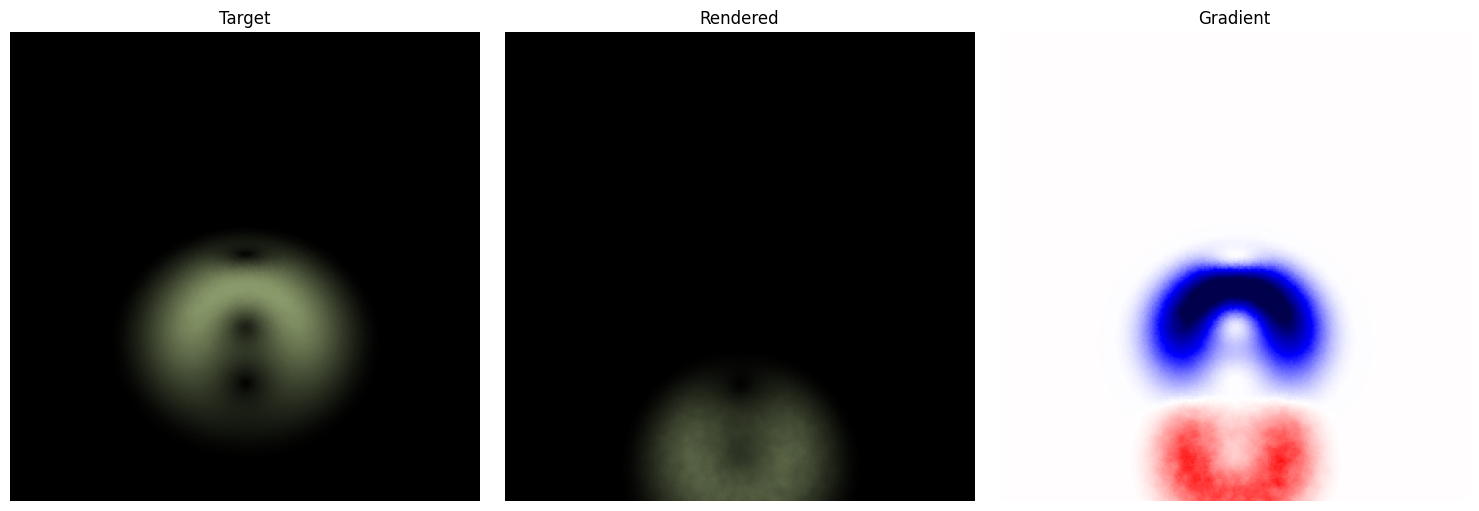

In [31]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Paths
iteration = 3
target_image = Path(f"Output/{scene}/{parameter}/{camera}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{test}/rendered/{iteration}_{camera}.png")
grad_image = Path(f"Output/{scene}/{parameter}/{test}/grad/{iteration}_{camera}.png")



# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)
img_grad = Image.open(grad_image)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

axes[2].imshow(img_grad)
axes[2].set_title("Gradient")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [32]:
print(df["analytic_grad"])
print(df[NUMERICAL_COLUMN])


0     0.000184
1     0.000141
2     0.000066
3    -0.000026
4    -0.000206
5    -0.000426
6    -0.000631
7    -0.000911
8    -0.001340
9    -0.001665
10   -0.001060
Name: analytic_grad, dtype: float64
0     1.018983e-04
1     9.480282e-05
2     1.127599e-04
3     1.021253e-04
4     2.561137e-07
5    -1.840701e-04
6    -4.241825e-04
7    -7.893133e-04
8    -1.325022e-03
9    -1.773189e-03
10   -1.166415e-03
Name: fd_grad, dtype: float64
